In [ ]:
%pip install pandas

**TASK-1: Displaying the housing.csv's first 10 rows**

In [ ]:
import pandas as pd
house_data = pd.read_csv('/Housing.csv')
house_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


**TASK-2: Data Cleaning**

In [ ]:
house_data.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
house_data.duplicated().sum()

np.int64(0)

No missing values or duplicates were found in the dataset therefore moving on to the task-3.

**TASK-3:Model Building**


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#values that do not have numerical values
categorical_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

#using padas directly converts numerical values for the values which do not have numerical values.
house_data = pd.get_dummies(
    house_data,
    columns=categorical_cols,
    drop_first=True
)

# X contains the independent variables (features)
# y contains the dependent variable (price)
X = house_data.drop('price', axis=1)
y = house_data['price']


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
#test size 20% and train size 80% as mentioned
    test_size=0.20,
    random_state=42
)


# Linear Regression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)


# Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)



print("\nModel Comparison")

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(comparison)

Linear Regression
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184

Random Forest Regressor
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699

Model Comparison
               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


**TASK-4:Data Visualization**


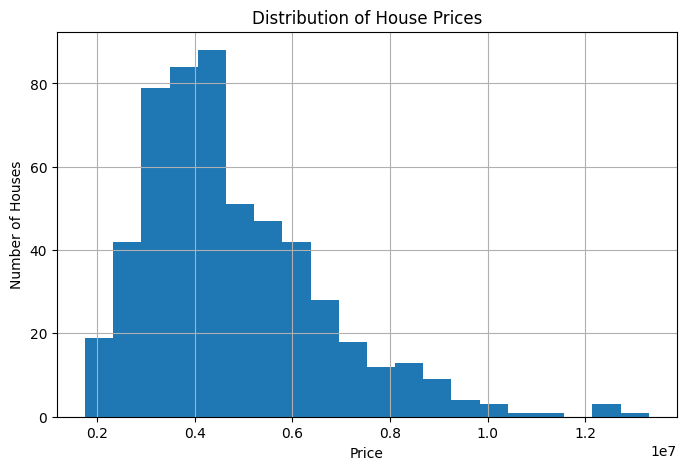

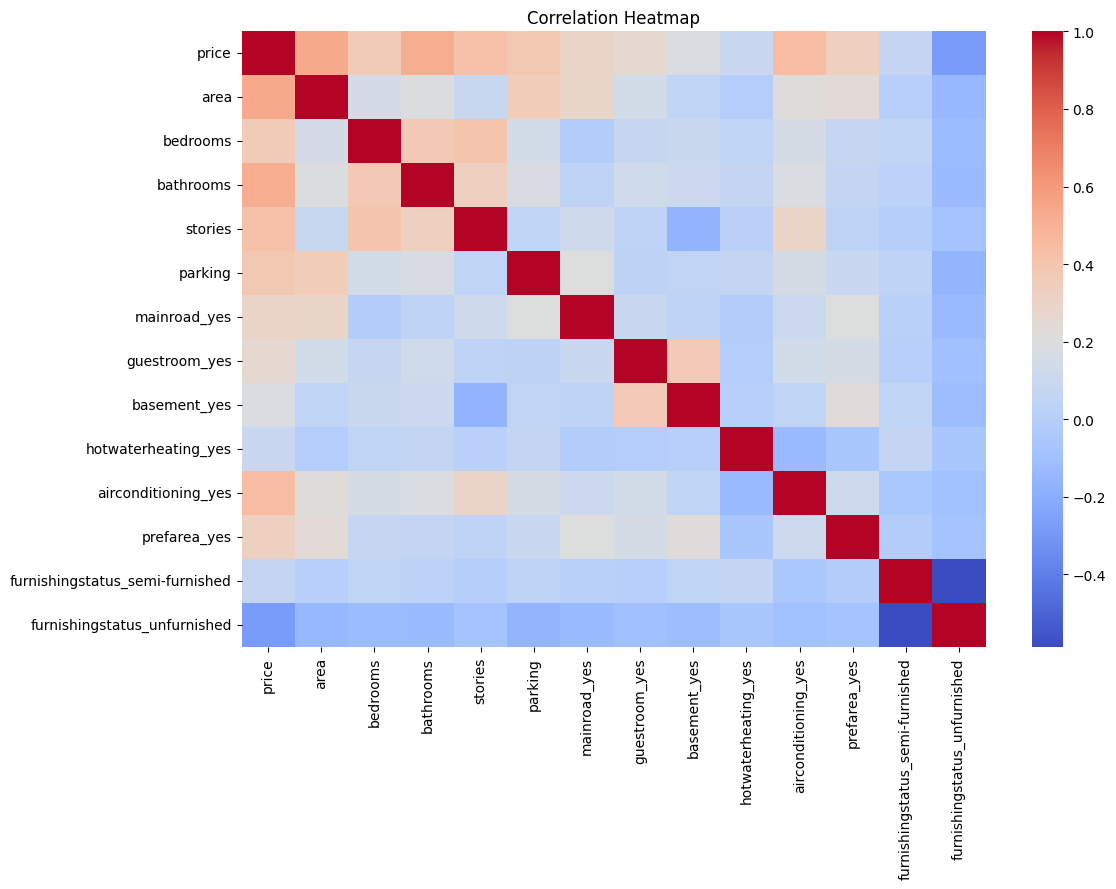

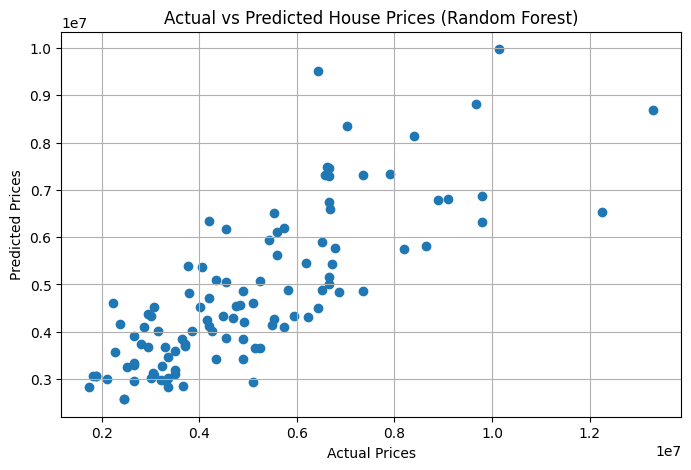

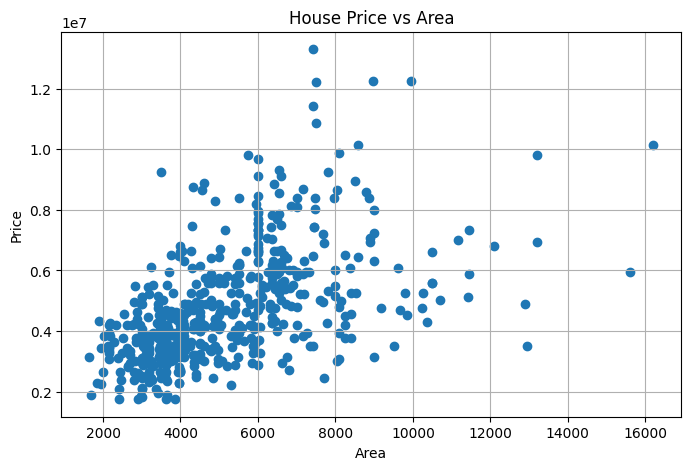

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Histogram of House Prices

plt.figure(figsize=(8, 5))
plt.hist(house_data['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.grid(True)
plt.show()


# Chart 2: Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    house_data.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()


# Chart 3: Actual vs Predicted Prices

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices (Random Forest)')

plt.grid(True)
plt.show()


#Chart 4: House Price vs Area

plt.figure(figsize=(8, 5))

plt.scatter(house_data['area'], house_data['price'])

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('House Price vs Area')

plt.grid(True)
plt.show()

**TASK-5:Insights and summary**


 The objective of this project was to predict house prices using various property features. From the correlation analysis, features such as area, bathrooms, stories, and parking showed a strong influence on house prices. Two regression models were trained and evaluated: Linear Regression and Random Forest Regressor.

The Linear Regression model achieved an R² score of **0.653**, meaning it explained approximately **65.3%** of the variation in house prices. It also achieved lower MAE and RMSE values compared to the Random Forest model, indicating more accurate predictions. The Random Forest Regressor achieved an R² score of **0.612**, which was slightly lower than that of Linear Regression.

One interesting observation was that a relatively simple **Linear Regression model outperformed** the more complex **Random Forest model**. This suggests that the relationship between the housing features and price is largely linear in this dataset.

Based on these findings, a real estate business should focus on factors such as **property area, number of bathrooms, number of stories, and parking availability** when pricing houses, as these features appear to have the strongest impact on property value.